Explainable Transformer Based Framework for Early Detection of Mental Health Disorders from Social Media Text

---

### imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path

RAW_DIR    = Path('..') / 'datasets' / 'raw'
CHARTS_DIR = Path('..') / 'results' / 'charts'
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})
sns.set_palette('muted')

---

### dataset 1 — sentiment analysis for mental health

In [2]:
df1 = pd.read_csv(RAW_DIR / 'Combined Data.csv')
df1['statement'] = df1['statement'].fillna('').astype(str)
df1['status']    = df1['status'].fillna('').astype(str)
print('shape :', df1.shape)
print('columns:', list(df1.columns))
print('missing:', df1.isnull().sum().to_dict())
df1.head(4)

shape : (53043, 3)
columns: ['Unnamed: 0', 'statement', 'status']
missing: {'Unnamed: 0': 0, 'statement': 0, 'status': 0}


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety


class counts:
status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201


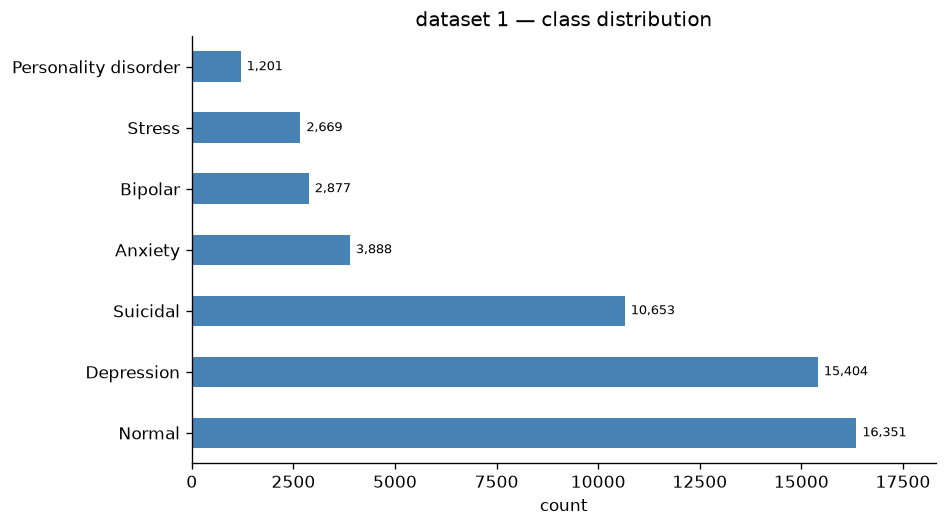

In [3]:
# class distribution
counts1 = df1['status'].value_counts()
print('class counts:')
print(counts1.to_string())

# horizontal bars — smallest class at top (matches reporting slide)
counts1_desc = counts1.sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4.5))
counts1_desc.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('dataset 1 — class distribution')
ax.set_xlabel('count')
ax.set_ylabel('')
for bar in ax.patches:
    ax.text(bar.get_width() + 150, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}', ha='left', va='center', fontsize=8)
ax.set_xlim(0, counts1.max() * 1.12)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'eda_ds1_class_distribution.png', bbox_inches='tight')
plt.show()

text length (words):
count    53043.0
mean       112.4
std        163.4
min          0.0
25%         15.0
50%         61.0
75%        147.5
max       6300.0


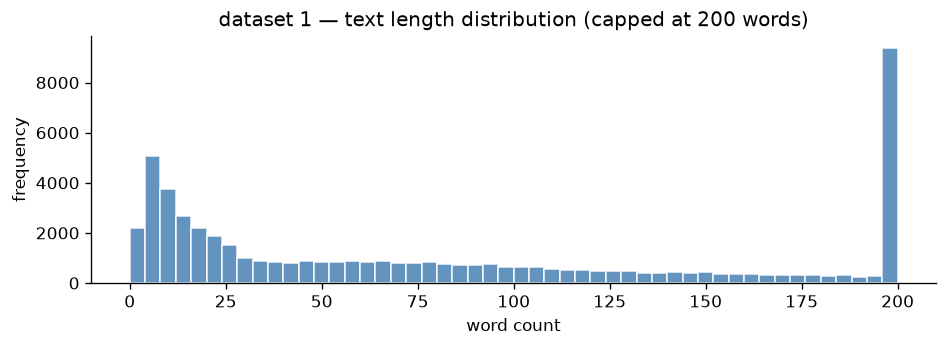

In [4]:
# text length analysis
df1['text_len'] = df1['statement'].str.split().str.len().fillna(0).astype(int)

print('text length (words):')
print(df1['text_len'].describe().round(1).to_string())

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(df1['text_len'].clip(upper=200), bins=50, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_title('dataset 1 — text length distribution (capped at 200 words)')
ax.set_xlabel('word count')
ax.set_ylabel('frequency')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'eda_ds1_text_length.png', bbox_inches='tight')
plt.show()

In [5]:
# sample texts per class
print('sample texts per class\n')
for label in df1['status'].unique():
    sample = df1[df1['status'] == label]['statement'].iloc[0]
    print(f'{label}:')
    print(f'  {str(sample)[:140]}')
    print()

sample texts per class

Anxiety:
  oh my gosh

Normal:
  Gr gr dreaming of ex crush to be my game, God

Depression:
  I recently went through a breakup and she said she still wants to be friends so I said I can try doing that but when she talks to me about t

Suicidal:
  I am so exhausted of this. Just when I think I can finally rest, just when I think maybe things are starting to settle, another hurdle comes

Stress:
  He said he had not felt that way before, suggeted I go rest and so ..TRIGGER AHEAD IF YOUI'RE A HYPOCONDRIAC LIKE ME: i decide to look up "f

Bipolar:
  What birth control are you on? I tried an IUD but it came out after a traumatic assault. I was taking microgestion but even at the lowest do

Personality disorder:
  Is there anyone interested in joining a group for AvPD on Telegram? **Edit:** The Telegram group has been created, here's the invitation lin



---

### dataset 2 — depression reddit cleaned

In [6]:
df2 = pd.read_csv(RAW_DIR / 'depression_dataset_reddit_cleaned.csv')
df2['clean_text']    = df2['clean_text'].fillna('').astype(str)
df2['is_depression'] = df2['is_depression'].astype(int)
print('shape :', df2.shape)
print('columns:', list(df2.columns))
print('missing:', df2.isnull().sum().to_dict())
df2.head(4)

shape : (7731, 2)
columns: ['clean_text', 'is_depression']
missing: {'clean_text': 0, 'is_depression': 0}


,clean_text,is_depression
0,we understand that most people who reply immed...,1
1,welcome to r depression s check in post a plac...,1
2,anyone else instead of sleeping more when depr...,1
3,i ve kind of stuffed around a lot in my life d...,1


class counts:
is_depression
Non-Depression    3900
Depression        3831


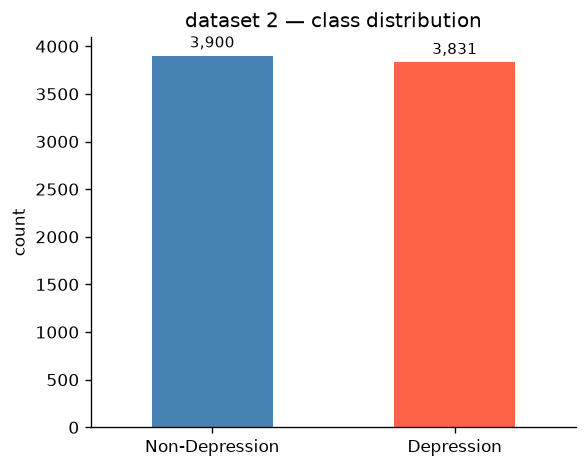

In [7]:
# class distribution
label_map = {0: 'Non-Depression', 1: 'Depression'}
counts2 = df2['is_depression'].map(label_map).value_counts()
print('class counts:')
print(counts2.to_string())

fig, ax = plt.subplots(figsize=(5, 4))
counts2.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
ax.set_title('dataset 2 — class distribution')
ax.set_xlabel('')
ax.set_ylabel('count')
ax.tick_params(axis='x', rotation=0)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'eda_ds2_class_distribution.png', bbox_inches='tight')
plt.show()

text length (words):
count    7731.0
mean       74.6
std       144.4
min         1.0
25%        12.0
50%        22.0
75%        76.0
max      4239.0


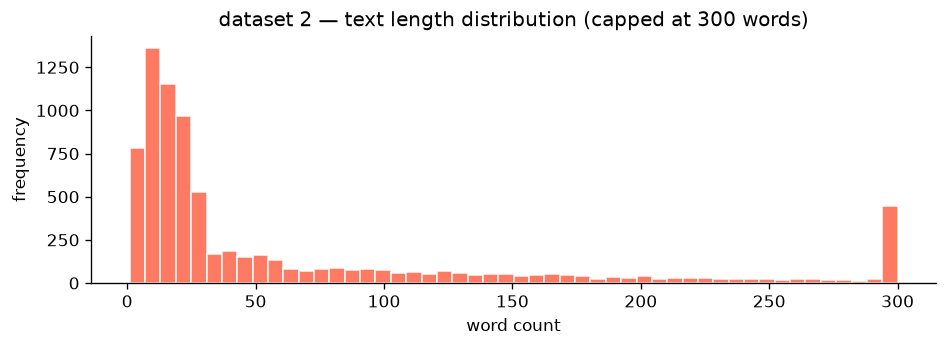

In [8]:
# text length analysis
df2['text_len'] = df2['clean_text'].str.split().str.len().fillna(0).astype(int)

print('text length (words):')
print(df2['text_len'].describe().round(1).to_string())

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(df2['text_len'].clip(upper=300), bins=50, color='tomato', edgecolor='white', alpha=0.85)
ax.set_title('dataset 2 — text length distribution (capped at 300 words)')
ax.set_xlabel('word count')
ax.set_ylabel('frequency')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'eda_ds2_text_length.png', bbox_inches='tight')
plt.show()

In [9]:
# sample texts
print('sample texts\n')
for label_val, label_name in label_map.items():
    sample = df2[df2['is_depression'] == label_val]['clean_text'].iloc[0]
    print(f'{label_name}:')
    print(f'  {str(sample)[:140]}')
    print()

sample texts

Non-Depression:
  switchfoot http twitpic com y zl awww that s a bummer you shoulda got david carr of third day to do it d

Depression:
  we understand that most people who reply immediately to an op with an invitation to talk privately mean only to help but this type of respon



---

### combined overview

In [10]:
total1 = len(df1)
total2 = len(df2)

summary = pd.DataFrame([
    {'dataset': 'Sentiment Analysis for Mental Health', 'rows': total1,
     'classes': df1['status'].nunique(), 'avg_words': round(df1['text_len'].mean(), 1),
     'missing': df1.isnull().sum().sum()},
    {'dataset': 'Depression Reddit Cleaned', 'rows': total2,
     'classes': df2['is_depression'].nunique(), 'avg_words': round(df2['text_len'].mean(), 1),
     'missing': df2.isnull().sum().sum()},
])

print(f'total samples across both datasets: {total1 + total2:,}')
print()
summary

total samples across both datasets: 60,774



,dataset,rows,classes,avg_words,missing
0,Sentiment Analysis for Mental Health,53043,7,112.4,0
1,Depression Reddit Cleaned,7731,2,74.6,0
